# Metoda gradientu prostego. Stosowanie do algorytmu wstecznej propagacji błędu

### Imports

In [40]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [41]:
import tensorflow as tf
import numpy as np
import os

x = tf.Variable(5.0, dtype=tf.float32)
y = tf.Variable(5.0, dtype=tf.float32)

target_fn = lambda x, y: 1.0 / tf.sqrt(x + 3.0 * y)
optimizer = tf.keras.optimizers.SGD(learning_rate=10.0)

x_list = [x.numpy()]
y_list = [y.numpy()]
cost_list = [target_fn(x, y).numpy()]

for epoch in range(250):

    with tf.GradientTape() as g:
        t = target_fn(x, y)

    gradients = g.gradient(t, sources=[x, y])
    optimizer.apply_gradients(zip(gradients, [x, y]))

    x.assign(tf.clip_by_value(x, 1.0, 10.0))
    y.assign(tf.clip_by_value(y, 1.0, 10.0))

    x_list.append(x.numpy())
    y_list.append(y.numpy())
    cost_list.append(target_fn(x, y).numpy())

    if epoch % 25 == 0 or epoch == 249:
        print(f"Epoka {epoch:3d}: f(x,y) = {t.numpy():.4f} | Położenie: x = {x.numpy():.4f}, y = {y.numpy():.4f}")

print(f"Minimum znalezione przez TensorFlow: x = {x.numpy():.2f}, y = {y.numpy():.2f}")
print(f"Najniższa wartość funkcji w punkcie końcowym: {target_fn(x, y).numpy():.4f}")

Epoka   0: f(x,y) = 0.2236 | Położenie: x = 5.0559, y = 5.1677
Epoka  25: f(x,y) = 0.1824 | Położenie: x = 6.0359, y = 8.1078
Epoka  50: f(x,y) = 0.1653 | Położenie: x = 6.6811, y = 10.0000
Epoka  75: f(x,y) = 0.1639 | Położenie: x = 7.2377, y = 10.0000
Epoka 100: f(x,y) = 0.1627 | Położenie: x = 7.7821, y = 10.0000
Epoka 125: f(x,y) = 0.1616 | Położenie: x = 8.3149, y = 10.0000
Epoka 150: f(x,y) = 0.1605 | Położenie: x = 8.8368, y = 10.0000
Epoka 175: f(x,y) = 0.1595 | Położenie: x = 9.3484, y = 10.0000
Epoka 200: f(x,y) = 0.1585 | Położenie: x = 9.8502, y = 10.0000
Epoka 225: f(x,y) = 0.1581 | Położenie: x = 10.0000, y = 10.0000
Epoka 249: f(x,y) = 0.1581 | Położenie: x = 10.0000, y = 10.0000
Minimum znalezione przez TensorFlow: x = 10.00, y = 10.00
Najniższa wartość funkcji w punkcie końcowym: 0.1581


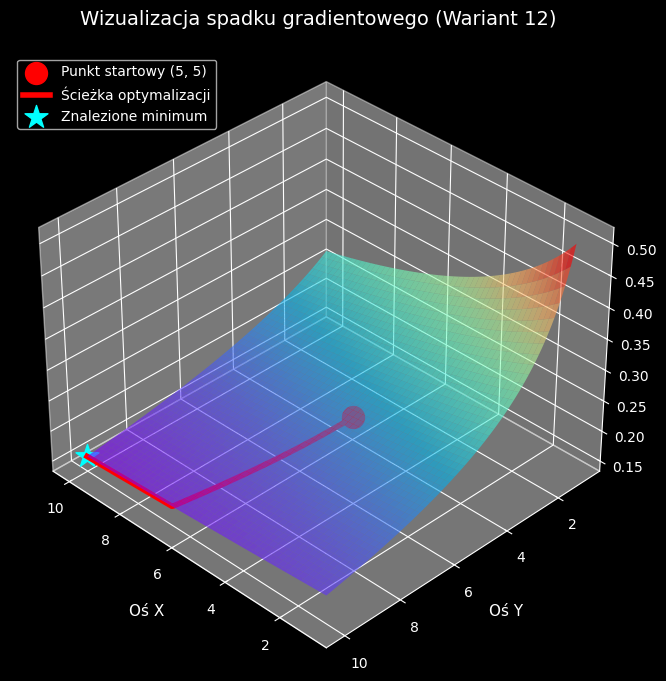

In [42]:
plt.style.use('dark_background')
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

x_space = np.linspace(1, 10, 100)
y_space = np.linspace(1, 10, 100)
x3D, y3D = np.meshgrid(x_space, y_space)

cost3D = 1.0 / np.sqrt(x3D + 3.0 * y3D)
surf = ax.plot_surface(x3D, y3D, cost3D, rstride=2, cstride=2, cmap='rainbow', alpha=0.6)
ax.scatter(x_list[0], y_list[0], cost_list[0], s=250, c='red', label='Punkt startowy (5, 5)', zorder=5)
ax.plot(x_list, y_list, cost_list, c='red', lw=4, label='Ścieżka optymalizacji', zorder=4)
ax.scatter(x_list[-1], y_list[-1], cost_list[-1], s=300, c='cyan', marker='*', label='Znalezione minimum', zorder=5)

ax.set_xlabel('Oś X', fontsize=11, labelpad=10)
ax.set_ylabel('Oś Y', fontsize=11, labelpad=10)
ax.set_zlabel('Wartość f(x,y)', fontsize=11, labelpad=10)
ax.set_title('Wizualizacja spadku gradientowego (Wariant 12)', fontsize=14, pad=20)
ax.legend(loc='upper left')

ax.view_init(elev=35, azim=135)

plt.savefig("wynik_optymalizacji_3D.png", dpi=300, bbox_inches='tight')
plt.show()

In [56]:
OUTPUT_DIR = "wykresy_animacja"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

print(f"Rozpoczęcie generowania {len(x_list)-1} klatek animacji do folderu './{OUTPUT_DIR}'...")

x_space = np.linspace(1, 10, 100)
y_space = np.linspace(1, 10, 100)
x3D, y3D = np.meshgrid(x_space, y_space)
cost3D = 1.0 / np.sqrt(x3D + 3.0 * y3D)

for angle in range(len(x_list) - 1):
    plt.style.use('dark_background')
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(x3D, y3D, cost3D, rstride=2, cstride=2, cmap='rainbow', alpha=0.6)
    ax.scatter(x_list[0], y_list[0], cost_list[0], s=250, c='red', label='Punkt startowy (5, 5)', zorder=5)
    ax.plot(x_list[:angle+1], y_list[:angle+1], cost_list[:angle+1], c='red', lw=4, label='Ścieżka optymalizacji', zorder=4)
    ax.scatter(x_list[angle], y_list[angle], cost_list[angle], s=300, c='cyan', marker='*', label='Aktualne położenie', zorder=5)

    ax.set_xlabel('Oś X', fontsize=11, labelpad=10)
    ax.set_ylabel('Oś Y', fontsize=11, labelpad=10)
    ax.set_zlabel('Wartość f(x,y)', fontsize=11, labelpad=10)
    ax.set_title(f'Wizualizacja spadku - Klatka {angle}', fontsize=14, pad=20)
    ax.legend(loc='upper left')

    ax.view_init(30 + (90 - angle)/5, 45 + angle*2)

    file_path = f"./{OUTPUT_DIR}/{str(angle).zfill(3)}.png"
    plt.savefig(file_path, dpi=150, bbox_inches='tight')
    plt.close()

print(f"Pliki zostały zapisane w katalogu: ./{OUTPUT_DIR}/")

Rozpoczęcie generowania 250 klatek animacji do folderu './wykresy_animacja'...
Sukces! Wszystkie pliki PNG zostały pomyślnie zapisane w katalogu: ./wykresy_animacja/


## Architektura

In [99]:
nn_architecture = [
    {"input_dim": 2, "output_dim": 2, "activation": "sigmoid"},
    {"input_dim": 2, "output_dim": 1, "activation": "elu"},
]

In [112]:
def init_layers(nn_architecture, seed = 99):
    np.random.seed(seed)
    number_of_layers = len(nn_architecture)
    params_values = {}

    for idx, layer in enumerate(nn_architecture):
        layer_idx = idx + 1
        print(idx)
        print(layer)
        layer_input_size = layer["input_dim"]
        layer_output_size = layer["output_dim"]

        params_values['W' + str(layer_idx)] = np.random.randn(
            layer_output_size, layer_input_size) * 0.1
        params_values['b' + str(layer_idx)] = np.random.randn(
            layer_output_size, 1) * 0.1

    return params_values

## Activation functions

In [101]:
def sigmoid(Z):
    return 1/(1+np.exp(-Z))

def relu(Z):
    return np.maximum(0,Z)

def sigmoid_backward(dA, Z):
    sig = sigmoid(Z)
    return dA * sig * (1 - sig)

def relu_backward(dA, Z):
    dZ = np.array(dA, copy = True)
    dZ[Z <= 0] = 0;
    return dZ;

def elu(Z, alpha=1.0):
    return np.where(Z > 0, Z, alpha * (np.exp(Z) - 1))

def elu_backward(dA, Z, alpha=1.0):
    # Pochodna: dla Z > 0 wynosi 1 (mnożone przez dA), dla Z <= 0 wynosi alpha * exp(Z) * dA
    dZ = np.where(Z > 0, 1.0, alpha * np.exp(Z))
    return dA * dZ

## Forward propagation

In [116]:
def single_layer_forward_propagation(A_prev, W_curr, b_curr, activation="relu"):
    #print(A_prev.shape)
    Z_curr = np.dot(W_curr, A_prev) + b_curr

    if activation == "relu":
        activation_func = relu
    elif activation == "sigmoid":
        activation_func = sigmoid
    elif activation == "elu":
        activation_func = elu
    else:
        raise Exception('Non-supported activation function')

    return activation_func(Z_curr), Z_curr

In [103]:
def full_forward_propagation(X, params_values, nn_architecture):
    memory = {}
    A_curr = X

    for idx, layer in enumerate(nn_architecture):
        layer_idx = idx + 1
        A_prev = A_curr

        activ_function_curr = layer["activation"]
        W_curr = params_values["W" + str(layer_idx)]
        b_curr = params_values["b" + str(layer_idx)]
        A_curr, Z_curr = single_layer_forward_propagation(A_prev, W_curr, b_curr, activ_function_curr)

        memory["A" + str(idx)] = A_prev
        memory["Z" + str(layer_idx)] = Z_curr

    return A_curr, memory

# Loss function (binary cross-entropy)

In [136]:
# def get_cost_value(Y_hat, Y):
#     m = Y_hat.shape[1]
#     cost = -1 / m * (np.dot(Y, np.log(Y_hat).T) + np.dot(1 - Y, np.log(1 - Y_hat).T))
#     return np.squeeze(cost)

def get_cost_value(Y_hat, Y):
    # Średnia kwadratów różnic między wynikiem sieci a rzeczywistością
    return np.mean((Y_hat - Y) ** 2)

# an auxiliary function that converts probability into class
def convert_prob_into_class(probs):
    probs_ = np.copy(probs)
    probs_[probs_ > 0.5] = 1
    probs_[probs_ <= 0.5] = 0
    return probs_

def get_accuracy_value(Y_hat, Y):
    Y_hat_ = convert_prob_into_class(Y_hat)
    return (Y_hat_ == Y).all(axis=0).mean()

## Backward propagation

$$\boldsymbol{dW}^{[l]} = \frac{\partial L }{\partial \boldsymbol{W}^{[l]}} = \frac{1}{m} \boldsymbol{dZ}^{[l]} \boldsymbol{A}^{[l-1] T}$$



$$\boldsymbol{db}^{[l]} = \frac{\partial L }{\partial \boldsymbol{b}^{[l]}} = \frac{1}{m} \sum_{i = 1}^{m} \boldsymbol{dZ}^{[l](i)}$$

$$\boldsymbol{dA}^{[l-1]} = \frac{\partial L }{\partial \boldsymbol{A}^{[l-1]}} = \boldsymbol{W}^{[l] T} \boldsymbol{dZ}^{[l]}$$

$$\boldsymbol{dZ}^{[l]} = \boldsymbol{dA}^{[l]} * g'(\boldsymbol{Z}^{[l]})$$

In [105]:
def single_layer_backward_propagation(dA_curr, W_curr, b_curr, Z_curr, A_prev, activation="relu"):
    m = A_prev.shape[1]

    if activation == "relu":
        backward_activation_func = relu_backward
    elif activation == "sigmoid":
        backward_activation_func = sigmoid_backward
    elif activation == "elu":
        backward_activation_func = elu_backward
    else:
        raise Exception('Non-supported activation function')

    dZ_curr = backward_activation_func(dA_curr, Z_curr)
    dW_curr = np.dot(dZ_curr, A_prev.T) / m
    db_curr = np.sum(dZ_curr, axis=1, keepdims=True) / m
    dA_prev = np.dot(W_curr.T, dZ_curr)

    return dA_prev, dW_curr, db_curr

$$\frac{\partial L }{\partial \boldsymbol{\hat{Y}}} = -(\frac{\boldsymbol{Y}}{\boldsymbol{\hat{Y}}}- \frac{1-\boldsymbol{Y}}{1-\boldsymbol{\hat{Y}}})$$

In [137]:
def full_backward_propagation(Y_hat, Y, memory, params_values, nn_architecture):
    grads_values = {}
    m = Y.shape[1]
    Y = Y.reshape(Y_hat.shape)

    #dA_prev = - (np.divide(Y, Y_hat) - np.divide(1 - Y, 1 - Y_hat));
    dA_prev = 2 * (Y_hat - Y) / m

    for layer_idx_prev, layer in reversed(list(enumerate(nn_architecture))):
        layer_idx_curr = layer_idx_prev + 1
        activ_function_curr = layer["activation"]

        dA_curr = dA_prev

        A_prev = memory["A" + str(layer_idx_prev)]
        Z_curr = memory["Z" + str(layer_idx_curr)]
        W_curr = params_values["W" + str(layer_idx_curr)]
        b_curr = params_values["b" + str(layer_idx_curr)]

        dA_prev, dW_curr, db_curr = single_layer_backward_propagation(
            dA_curr, W_curr, b_curr, Z_curr, A_prev, activ_function_curr)

        grads_values["dW" + str(layer_idx_curr)] = dW_curr
        grads_values["db" + str(layer_idx_curr)] = db_curr

    return grads_values

## Updating the parameters (Gradient descent)

In [107]:
def update(params_values, grads_values, nn_architecture, learning_rate):
    for idx, layer in enumerate(nn_architecture):
        layer_idx = idx + 1
        params_values["W" + str(layer_idx)] -= learning_rate * grads_values["dW" + str(layer_idx)]
        params_values["b" + str(layer_idx)] -= learning_rate * grads_values["db" + str(layer_idx)]

    return params_values

## Training (putting things together): Error backpropagation algorithm

In [138]:
def train(X, Y, nn_architecture, epochs, learning_rate):
    params_values = init_layers(nn_architecture, 2)
    cost_history = []
    accuracy_history = []

    for i in range(epochs):
        Y_hat, cache = full_forward_propagation(X, params_values, nn_architecture)
        cost = get_cost_value(Y_hat, Y)
        cost_history.append(cost)
        accuracy = get_accuracy_value(Y_hat, Y)
        accuracy_history.append(accuracy)

        grads_values = full_backward_propagation(Y_hat, Y, cache, params_values, nn_architecture)
        params_values = update(params_values, grads_values, nn_architecture, learning_rate)

    return params_values, cost_history, accuracy_history

## Example

In [165]:
# x = np.array([[1,2],[3,4],[2,3],[4,5]])
# y = np.array([[3],[4],[5],[3]])
#y = np.squeeze(np.asarray(y))

X_train = np.array([[0.1, 0.2],[0.5, 0.8],[0.15, 0.3], [0.85, 0.9]])
Y_train = np.array([[1],[0],[1],[0]])

X_test = np.array([[0.2, 0.2], [0.1, 0.4], [0.6, 0.5]])
Y_test = np.array([[1], [1], [0]])

X = X_train.T
Y = Y_train.T

X_t = X_test.T
Y_t = Y_test.T



In [163]:
#simple_model_1 = train(X,Y, nn_architecture, 800, 5)
params_values, cost_history, accuracy_history =  train(X,Y, nn_architecture, 500, 0.1)
print("Pierwsze 5 wartości kosztu:", cost_history[:5])
print("Ostatnie 5 wartości kosztu:", cost_history[-5:])
print(f"Końcowa celność (accuracy): {accuracy_history[-1] * 100}%")

Y_hat_test, _ = full_forward_propagation(X_t, params_values, nn_architecture)

# 4. Liczymy celność na nowych danych
test_accuracy = get_accuracy_value(Y_hat_test, Y_t)

print("-" * 40)
print(f"Celność na zbiorze testowym: {test_accuracy * 100}%")

0
{'input_dim': 2, 'output_dim': 2, 'activation': 'sigmoid'}
1
{'input_dim': 2, 'output_dim': 1, 'activation': 'elu'}
Pierwsze 5 wartości kosztu: [np.float64(0.6510495025988139), np.float64(0.6080659817450644), np.float64(0.5666415400154423), np.float64(0.5271572098967123), np.float64(0.4900225134545341)]
Ostatnie 5 wartości kosztu: [np.float64(0.23117549218154335), np.float64(0.23109972383702193), np.float64(0.2310237028375549), np.float64(0.2309474285669584), np.float64(0.23087090040975314)]
Końcowa celność (accuracy): 100.0%
----------------------------------------
Celność na zbiorze testowym: 100.0%
